<a href="https://colab.research.google.com/github/SirTEdgar/Aviation-Assignment/blob/main/CGLabC4M3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer using Big Data Tools

### Step 0

You are part of a research team using Big Data tools to help oncologists identify breast cancer cases more efficiently. To analyze large datasets effectively, you're asked to set up a reliable computing environment using PySpark. This step ensures your tools are ready, setting the foundation for a scalable and collaborative analysis.


**Import the germane library**

In [1]:
# CodeGrade step0
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a Spark session
spark = SparkSession.builder \
    .appName("Breast Cancer Analysis") \
    .getOrCreate()

### Step 1

You need a fast and distributed framework for real-time data processing. By creating a Spark session, you're simulating how hospital systems manage real-time data, ensuring the analysis pipeline is efficient and functional.

**Create a Spark session where the name is "Breast Cancer Analysis" and verify that it is running by using this:**

```
if (spark.getActiveSession()):
    print('yes')
else:
    print('no')
```

In [2]:
# CodeGrade step1

from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a spark session

# Verify the spark session- named "Breast Cancer Analysis"- is running

# Load the breast cancer data using spark.read.csv

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Breast Cancer Analysis") \
    .getOrCreate()

print("Spark Session is running!")
print("Application Name:", spark.sparkContext.appName)
print("Spark Version:", spark.version)

Spark Session is running!
Application Name: Breast Cancer Analysis
Spark Version: 4.0.4


# Step 2

 Hospitals often store patient data in distributed databases. To prepare for further analysis and visualizations, you're tasked with loading the breast cancer dataset into Spark and converting it into a Pandas DataFrame. This mirrors the real-world task of preparing large datasets for team collaboration and actionable insights.


* **Load the data**
* **Create `df_pandas = spark_df.toPandas()`**

In [ ]:
# CodeGrade step0

# Load the dataset into a PySpark DataFrame
spark_df = spark.read.csv("breast_cancer.csv", header=True, inferSchema=True)

In [4]:
# CodeGrade step2
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the dataset
data = load_breast_cancer()

# Create a Pandas DataFrame first
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target column
df["target"] = data.target

# Convert Pandas DataFrame to Spark DataFrame
spark_df = spark.createDataFrame(df)

# Display the Spark DataFrame
spark_df.show(5)

+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+------+
|mean radius|mean texture|mean perimeter|mean area|mean smoothness|mean compactness|mean concavity|mean concave points|mean symmetry|mean fractal dimension|radius error|texture error|perimeter error|area error|smoothness error|compactness error|concavity error|concave points error|symmetry error|fractal dimension error|worst radius|worst texture|worst perimeter|worst area|worst smoothness|worst compactness|worst concavity|worst concave points|worst symmetry|worst fractal dimension|target|
+-----------

### Step 3

As a new hire, your manager wants you to understand the structure of the dataset before diving into analysis. Displaying records and data types ensures you comprehend the data's shape and quality, just like how doctors ensure they have complete patient records before making decisions.

*   **Load the data**
*   **Display records and data types**
*.  **Give (not print) the rows and columns in this format**
```
num_rows
num_cols
```







In [ ]:
# Run this code

# Display schema and first few rows
spark_df.printSchema()
spark_df.show(5)

In [5]:
# CodeGrade step3
# Display the first 5 records
spark_df.show(5)

# Display the data types
spark_df.printSchema()

# Get number of rows and columns
num_rows = spark_df.count()
num_cols = len(spark_df.columns)

# Give the rows and columns in the required format
num_rows
num_cols

+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+------+
|mean radius|mean texture|mean perimeter|mean area|mean smoothness|mean compactness|mean concavity|mean concave points|mean symmetry|mean fractal dimension|radius error|texture error|perimeter error|area error|smoothness error|compactness error|concavity error|concave points error|symmetry error|fractal dimension error|worst radius|worst texture|worst perimeter|worst area|worst smoothness|worst compactness|worst concavity|worst concave points|worst symmetry|worst fractal dimension|target|
+-----------

31

### Step 4

The dataset you’re working with may contain inconsistencies, just as hospital records sometimes do. Cleaning the data helps ensure the findings are reliable and aligns with your responsibility to maintain high standards in healthcare analytics.

*   **Select the 50th row**
  * **Call this `row_50`**
* **Find the radius mean value value of the 50th row**
  * **Call this `radius_mean_value`**

In [6]:
# CodeGrade step4
# Select the 50th row
row_50 = spark_df.collect()[49]

# Find the radius mean value
radius_mean_value = row_50["mean radius"]

radius_mean_value

13.49

### Step 5

You’re tasked with helping oncologists identify critical patterns. By focusing on key features in the dataset, you’re pinpointing variables that significantly impact diagnoses, guiding doctors in making evidence-based decisions

* **Find the counts of the number of malignant and benign diagnosis**
  * **Call these `m_count` and `b_count`, respectively**
* **Then take the difference of malignant and benign**
  * **Call this `diagnosis_diff`**


In [7]:
# CodeGrade step5
# Count malignant and benign diagnoses
m_count = spark_df.filter(spark_df["target"] == 0).count()
b_count = spark_df.filter(spark_df["target"] == 1).count()

# Find the difference
diagnosis_diff = m_count - b_count

m_count
b_count
diagnosis_diff

-145

### Step 6

A chief oncologist asks you to present findings to a panel. Visualizing the data allows you to communicate complex results effectively, enabling stakeholders to grasp critical insights that aid in policy decisions or medical strategies.

Create a *relative frequency* bar plot to show the distribution of benign and malignant cases. **bold text**
* **Call the Plot "Diagnosis Class Balance", the x-axis "Diagnosis", and the y-axis "Relative Frequency"**
* **Print the relative frequency of the Malignant cases**
  * **The last line of code should be**
    > **`relative_frequencies['M']`**



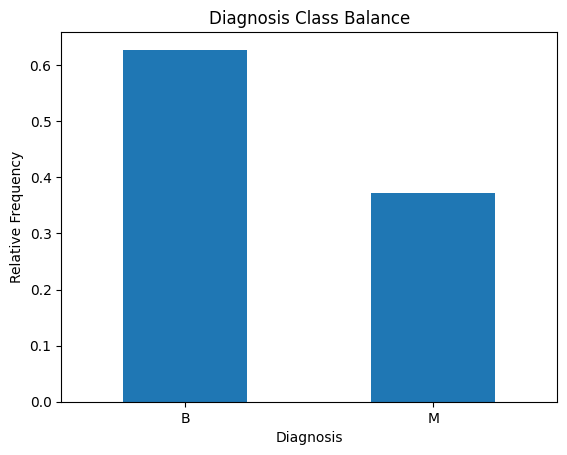

np.float64(0.37258347978910367)

In [8]:
#CodeGrade step6
import matplotlib.pyplot as plt

# Create diagnosis labels
diagnosis = spark_df.select("target").toPandas()
diagnosis["diagnosis"] = diagnosis["target"].map({
    0: "M",
    1: "B"
})

# Calculate relative frequencies
relative_frequencies = diagnosis["diagnosis"].value_counts(normalize=True)

# Create the relative frequency bar plot
relative_frequencies.plot(kind="bar")

plt.title("Diagnosis Class Balance")
plt.xlabel("Diagnosis")
plt.ylabel("Relative Frequency")
plt.xticks(rotation=0)
plt.show()

# Print relative frequency of malignant cases
relative_frequencies['M']

### Step 7

In the fight against cancer, the insights drawn depend heavily on the way data is processed. By creating new features or transforming existing ones, you're emulating how doctors refine raw observations into meaningful diagnostic indicators. This task helps extract deeper insights from the dataset, simulating the development of more precise diagnostic tools.

**Use PySpark's `.describe()` to see statistics for each feature, which will help you understand the ranges and distributions of the data.**

**Convert the PySpark DataFrame to Pandas for these calculations:**
* **maximum of the `fractal_dimension_mean`**
  * **Call this `max_fractal_dimension_mean`**
* **minimum of the `symmetry_mean`**
  * **Call this `min_symmetry_mean`**

**Take the absolute value of the difference of the `max_fractal_dimension_mean` and `min_symmetry_mean`.**
*  **Round to four decimal places**
*  **Call this `range_diff`**

In [ ]:
# Run this code

# Use PySpark to describe the dataset
spark_df.describe().show()

In [9]:
#CodeGrade step7

# Use PySpark describe() to view statistics
spark_df.describe().show()

+-------+------------------+-----------------+------------------+------------------+--------------------+--------------------+-------------------+-------------------+--------------------+----------------------+-------------------+------------------+------------------+------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-----------------------+------------------+------------------+------------------+-----------------+-------------------+-------------------+-------------------+--------------------+-------------------+-----------------------+------------------+
|summary|       mean radius|     mean texture|    mean perimeter|         mean area|     mean smoothness|    mean compactness|     mean concavity|mean concave points|       mean symmetry|mean fractal dimension|       radius error|     texture error|   perimeter error|        area error|    smoothness error|   compactness error|    concavity error|concave points e

In [10]:
# Convert Spark DataFrame to Pandas
df_pandas = spark_df.toPandas()

# Find the maximum fractal dimension mean
max_fractal_dimension_mean = df_pandas["fractal_dimension_mean"].max()

# Find the minimum symmetry mean
min_symmetry_mean = df_pandas["symmetry_mean"].min()

# Calculate the absolute difference and round to 4 decimal places
range_diff = round(
    abs(max_fractal_dimension_mean - min_symmetry_mean),
    4
)

range_diff

KeyError: 'fractal_dimension_mean'

In [11]:
df_pandas.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [12]:
# Display statistics using PySpark
spark_df.describe().show()

# Convert Spark DataFrame to Pandas
df_pandas = spark_df.toPandas()

# Calculate the required values
max_fractal_dimension_mean = df_pandas["mean fractal dimension"].max()
min_symmetry_mean = df_pandas["mean symmetry"].min()

# Calculate absolute difference and round to 4 decimal places
range_diff = round(
    abs(max_fractal_dimension_mean - min_symmetry_mean),
    4
)

range_diff

+-------+------------------+-----------------+------------------+------------------+--------------------+--------------------+-------------------+-------------------+--------------------+----------------------+-------------------+------------------+------------------+------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-----------------------+------------------+------------------+------------------+-----------------+-------------------+-------------------+-------------------+--------------------+-------------------+-----------------------+------------------+
|summary|       mean radius|     mean texture|    mean perimeter|         mean area|     mean smoothness|    mean compactness|     mean concavity|mean concave points|       mean symmetry|mean fractal dimension|       radius error|     texture error|   perimeter error|        area error|    smoothness error|   compactness error|    concavity error|concave points e

0.0086

### Step 8

You’re part of a team developing an AI system to assist doctors in identifying potential cancer cases. By building predictive models, you’re taking a crucial step toward automating diagnosis, helping reduce the workload on medical professionals while improving patient outcomes.


Let's suppose that you have reason to believe that the product of the 'radius_mean', 'texture_mean', and 'perimeter_mean' is meaningful to verify a diagnosis of Benign.

Use pandas to find the **bold text**
*   **Average of `radius_mean`, `texture_mean`, and `perimeter_mean` for each diagnosis (all three rounded to two decimal places) only for the Benign case**
  * **Call these, respectively, `radius_mean_b`, `texture_mean_b`, and `perimeter_mean_b`**
*   **Return only the product of the these three rounded means (and multiply in the order given)**

In [13]:
#CodeGrade step08

benign = df_pandas[df_pandas["target"] == 1]

radius_mean_b = round(benign["mean radius"].mean(), 2)
texture_mean_b = round(benign["mean texture"].mean(), 2)
perimeter_mean_b = round(benign["mean perimeter"].mean(), 2)

radius_mean_b * texture_mean_b * perimeter_mean_b

np.float64(16990.71552)

### Step 9

A hospital’s board of directors is reviewing the accuracy and reliability of your system before rolling it out. Evaluating the model ensures that it’s trustworthy and aligns with the hospital's commitment to high standards of care. Your analysis helps build confidence in the tool’s ability to assist in life-saving decisions.

Let's suppose that you have reason to believe that the average of the ratio of the `radius_mean` and the `perimeter_mean` are meaningful for the Malignant cases.

**Use pandas to compute**

*   **Average of the ratio of the `radius_mean` and the `perimeter_mean` only for the Malignant cases**
  * **Call this `ratios`**
*   **Round this to two decimal places**
  * **Call the result `mean_radius_perimeter_ratio`**


In [14]:
# CodeGrade step9

malignant = df_pandas[df_pandas["target"] == 0]

ratios = malignant["mean radius"] / malignant["mean perimeter"]

mean_radius_perimeter_ratio = round(ratios.mean(), 2)

mean_radius_perimeter_ratio


np.float64(0.15)

In [15]:
df_pandas.columns.tolist()

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

### Step 10


**Close the spark session, where verification that it is closed will result in the output of 'yes'**
*    ***Hint*: Use code similar to what was used in Step 1.**



In [16]:
# CodeGrade step10

# Step 10
spark.stop()
print("yes")

yes
